# Session 1: Logistic Regression for Fake News Detection

**Fake News Detection on Twitter — Model Landscape, Part 1**

By the end of this notebook you will be able to:
- Explain *why* Logistic Regression is a strong baseline for text classification
- Derive, in plain language, how it turns a TF-IDF vector into a "Real" / "Fake" decision
- Train, evaluate, and interpret a Logistic Regression classifier on tweet data

> **Prerequisite recap:** you've already covered text preprocessing (cleaning, tokenization, stopword removal) and feature extraction (TF-IDF). This notebook picks up right where that left off — we'll quickly regenerate a TF-IDF matrix and then spend most of our time on the model itself.

## 0. Setup

We'll build a small synthetic tweet dataset so this notebook runs end-to-end without needing any external download. In your actual project, replace this cell with your real labeled tweet dataset (e.g. loaded from a CSV via `pd.read_csv()`).

In [1]:
# Install (Colab usually has these already, this is just a safety net)
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [8]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK resources (only runs once, then cached)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


# ============================================================
# STEP 2: LOAD THE DATASET
# ============================================================
# Most Kaggle "Fake News Detection" datasets come as two separate files:
#   Fake.csv  -> all fake news articles
#   True.csv  -> all real news articles
# Adjust the paths below to match where you uploaded your files.

fake_df = pd.read_csv("Fake.csv")
real_df = pd.read_csv("True.csv")

# Add a label column to each before combining
fake_df["label"] = "Fake"
real_df["label"] = "Real"

print("Fake news rows:", fake_df.shape[0])
print("Real news rows:", real_df.shape[0])
print(fake_df.head())


# ============================================================
# STEP 3: COMBINE INTO A SINGLE DATAFRAME
# ============================================================
df = pd.concat([fake_df, real_df], axis=0, ignore_index=True)

# Shuffle the rows so Fake/Real aren't grouped in blocks
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nCombined dataset shape:", df.shape)
print(df["label"].value_counts())


# ============================================================
# STEP 4: HANDLE MISSING / DUPLICATE DATA
# ============================================================
print("\nMissing values per column:\n", df.isnull().sum())

# Drop rows where the main text column is missing
df.dropna(subset=["text"], inplace=True)

# Drop exact duplicate articles
df.drop_duplicates(subset=["text"], inplace=True)

print("\nShape after dropping missing/duplicate text:", df.shape)


# ============================================================
# STEP 5: TEXT CLEANING
# ============================================================
# Removes URLs, HTML tags, mentions, hashtags, punctuation, numbers, and extra whitespace

def clean_text(text):
    text = str(text).lower()                                  # lowercase
    text = re.sub(r"https?://\S+|www\.\S+", "", text)          # remove URLs
    text = re.sub(r"<.*?>", "", text)                          # remove HTML tags
    text = re.sub(r"@\w+", "", text)                           # remove mentions
    text = re.sub(r"#\w+", "", text)                           # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)                       # remove punctuation/numbers/special chars
    text = re.sub(r"\s+", " ", text).strip()                   # collapse multiple spaces
    return text

df["clean_text"] = df["text"].apply(clean_text)

print("\nBefore cleaning:\n", df["text"].iloc[0])
print("\nAfter cleaning:\n", df["clean_text"].iloc[0])


# ============================================================
# STEP 6: TOKENIZATION
# ============================================================
# Breaks each cleaned sentence into a list of individual words

df["tokens"] = df["clean_text"].apply(word_tokenize)

print("\nTokenized example:\n", df["tokens"].iloc[0])


# ============================================================
# STEP 7: STOPWORD REMOVAL
# ============================================================
# Removes common words (the, is, at, and, etc.) that carry little classification signal

stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["tokens_no_stopwords"] = df["tokens"].apply(remove_stopwords)

print("\nAfter stopword removal:\n", df["tokens_no_stopwords"].iloc[0])


# ============================================================
# STEP 8: LEMMATIZATION
# ============================================================
# Reduces words to their dictionary root form (e.g. "running" -> "run", "studies" -> "study")

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["lemmatized_tokens"] = df["tokens_no_stopwords"].apply(lemmatize_tokens)

print("\nAfter lemmatization:\n", df["lemmatized_tokens"].iloc[0])


# ============================================================
# STEP 9: REJOIN TOKENS INTO FINAL CLEAN TEXT
# ============================================================
# This final string column is what gets fed into TfidfVectorizer / CountVectorizer
# in the next stage (feature extraction).

df["final_text"] = df["lemmatized_tokens"].apply(lambda tokens: " ".join(tokens))

print("\nFinal processed text:\n", df["final_text"].iloc[0])


# ============================================================
# STEP 10: ENCODE LABELS
# ============================================================
# Convert text labels into numeric form for modeling: Real = 0, Fake = 1

df["label_num"] = df["label"].map({"Real": 0, "Fake": 1})


# ============================================================
# STEP 11: REMOVE EMPTY ROWS AFTER CLEANING
# ============================================================
# Some rows may become empty strings after aggressive cleaning (e.g. text that was only a URL)

df = df[df["final_text"].str.strip() != ""]
df.reset_index(drop=True, inplace=True)

print("\nFinal dataset shape after full preprocessing:", df.shape)


# ============================================================
# STEP 12: SAVE THE CLEANED DATASET
# ============================================================
# Save a checkpoint so the next stage (feature extraction) doesn't need to repeat this work

final_df = df[["final_text", "label", "label_num"]]
final_df.to_csv("cleaned_fake_news_dataset.csv", index=False)

print("\nCleaned dataset saved as 'cleaned_fake_news_dataset.csv'")
print(final_df.head())

Fake news rows: 23481
Real news rows: 21417
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date label  
0  December 31, 2017  Fake  
1  December 31, 2017  Fake  
2  December 30, 2017  Fake  
3  December 29, 2017  Fake  
4  December 25, 2017  Fake  

Combined dataset shape: (44898, 5)
label
Fake    23481
Real

## 1. Quick Recap: Preprocessing → TF-IDF

You've already built this pipeline in the previous sessions. We rebuild it briefly here so this notebook is self-contained.

**Reminder of what each step does:**
- **Cleaning:** strip URLs, mentions, hashtags, punctuation
- **Normalization:** lowercase everything
- **Vectorization (TF-IDF):** convert each tweet into a vector of numbers, one per vocabulary word, where the value reflects how *important* that word is to that tweet relative to the whole corpus

The output of this stage is a matrix: **rows = tweets, columns = vocabulary words, values = TF-IDF scores.** This matrix is what every model in this course (Logistic Regression, Naive Bayes, SVM) will actually train on.

In [9]:
# ============================================================
# LOAD THE CLEANED DATASET (output of preprocessing stage)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

df = pd.read_csv("cleaned_fake_news_dataset.csv")

print("Loaded shape:", df.shape)
print(df.head())


# ============================================================
# TRAIN/TEST SPLIT — before vectorizing, to avoid data leakage
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    df["final_text"], df["label_num"],
    test_size=0.2, random_state=42, stratify=df["label_num"]
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


# ============================================================
# TF-IDF VECTORIZATION
# ============================================================
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)   # learn vocabulary + transform
X_test_tfidf = vectorizer.transform(X_test)          # reuse the SAME vocabulary

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

Loaded shape: (38590, 3)
                                          final_text label  label_num
0  st century wire say ben stein reputable profes...  Fake          1
1  washington reuters u president donald trump re...  Real          0
2  reuters puerto rico governor ricardo rossello ...  Real          0
3  monday donald trump embarrassed country accide...  Fake          1
4  glasgow scotland reuters u presidential candid...  Real          0
Train size: 30872
Test size: 7718
TF-IDF matrix shape (train): (30872, 5000)
TF-IDF matrix shape (test): (7718, 5000)


In [10]:
# def clean_text(text):
#     text = text.lower()
#     text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
#     text = re.sub(r"#\w+", "", text)                # remove hashtags
#     text = re.sub(r"@\w+", "", text)                # remove mentions
#     text = re.sub(r"[^a-z\s]", "", text)             # remove punctuation/numbers
#     text = re.sub(r"\s+", " ", text).strip()         # collapse whitespace
#     return text

# df['clean_text'] = df['text'].apply(clean_text)
# df['label_num'] = df['label'].map({'Real': 0, 'Fake': 1})  # 0 = Real, 1 = Fake

# df[['text', 'clean_text', 'label']].head()

In [11]:
# # Train/test split BEFORE vectorizing, to avoid data leakage
# X_train, X_test, y_train, y_test = train_test_split(
#     df['clean_text'], df['label_num'],
#     test_size=0.2, random_state=42, stratify=df['label_num']
# )

# print("Train size:", X_train.shape[0])
# print("Test size:", X_test.shape[0])

In [12]:
# vectorizer = TfidfVectorizer(max_features=3000)

# X_train_tfidf = vectorizer.fit_transform(X_train)   # learn vocabulary + transform
# X_test_tfidf = vectorizer.transform(X_test)          # reuse the SAME vocabulary

# print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
# print("TF-IDF matrix shape (test):", X_test_tfidf.shape)
# print("\nThis means: each of the", X_train_tfidf.shape[0], "tweets is now represented as a vector of",
#       X_train_tfidf.shape[1], "numbers.")

## 2. The Core Question

We now have, for every tweet, a vector of a few thousand numbers (most of them zero — this is what we mean by **sparse**, high-dimensional data).

**The question Logistic Regression answers:**

> Given this vector of numbers, how do we combine them into a single decision: *Real* or *Fake*?

The intuition is simple: **every word gets a learned weight.**

- A word like `"secretly"` might get a strongly *positive* weight → pushes the tweet toward "Fake"
- A word like `"reuters"` might get a strongly *negative* weight → pushes the tweet toward "Real"
- Most words get a weight close to zero → they don't help distinguish the classes

Logistic Regression's job is to **learn these weights from data**, then for a new tweet, multiply each word's TF-IDF value by its learned weight, and add everything up.

## 3. The Math: From a Weighted Sum to a Probability

### Step 1 — The linear combination

For a tweet represented as a feature vector $x = (x_1, x_2, ..., x_n)$ (the TF-IDF values), Logistic Regression first computes a weighted sum, exactly like a regular linear equation:

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

Where:
- $x_i$ = TF-IDF value of word $i$ in this tweet
- $w_i$ = the learned **weight** (importance) of word $i$
- $b$ = a **bias** term (a constant offset, learned too)

This $z$ can be **any real number** — from very negative to very positive. A large positive $z$ should mean "very likely Fake," a large negative $z$ should mean "very likely Real."

### Step 2 — Why we can't stop at $z$

$z$ isn't a probability — it's unbounded. We need to **squash** it into the range $[0, 1]$ so it can be interpreted as $P(\text{Fake} \mid \text{tweet})$.

### Step 3 — The Sigmoid function

This is exactly what the **sigmoid function** does:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Properties worth noting:
- As $z \to +\infty$, $\sigma(z) \to 1$
- As $z \to -\infty$, $\sigma(z) \to 0$
- At $z = 0$, $\sigma(z) = 0.5$ exactly

So the full Logistic Regression model is:

$$P(\text{Fake} \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

### Step 4 — Making the decision

$$\hat{y} = \begin{cases} \text{Fake} & \text{if } P(\text{Fake}\mid \mathbf{x}) \geq 0.5 \\ \text{Real} & \text{if } P(\text{Fake}\mid \mathbf{x}) < 0.5 \end{cases}$$

Geometrically: the set of points where $\mathbf{w}^T\mathbf{x} + b = 0$ defines a **straight line** (or, in higher dimensions, a **hyperplane**) that separates the two classes in the TF-IDF feature space. Logistic Regression is, at its heart, a **linear classifier**.

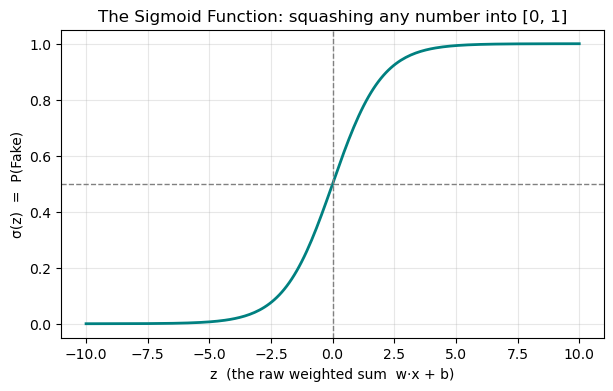

sigmoid(-5) = 0.0066928509242848554  -> strongly predicts REAL
sigmoid(0)  = 0.5  -> exactly undecided (50/50)
sigmoid(5)  = 0.9933071490757153  -> strongly predicts FAKE


In [13]:
# Let's SEE the sigmoid function before we use it inside a real model

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
sig_values = sigmoid(z_values)

plt.figure(figsize=(7, 4))
plt.plot(z_values, sig_values, linewidth=2, color='teal')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title("The Sigmoid Function: squashing any number into [0, 1]")
plt.xlabel("z  (the raw weighted sum  w·x + b)")
plt.ylabel("σ(z)  =  P(Fake)")
plt.grid(alpha=0.3)
plt.show()

print("sigmoid(-5) =", sigmoid(-5), " -> strongly predicts REAL")
print("sigmoid(0)  =", sigmoid(0),  " -> exactly undecided (50/50)")
print("sigmoid(5)  =", sigmoid(5),  " -> strongly predicts FAKE")

## 4. How the Weights Are Learned

The weights $w_i$ aren't guessed — they're **learned** from the training data by minimizing a loss function.

### Log Loss (Binary Cross-Entropy)

For a single training example with true label $y \in \{0, 1\}$ and predicted probability $\hat{p} = \sigma(z)$:

$$\mathcal{L}(y, \hat{p}) = -\big[y \log(\hat{p}) + (1-y)\log(1-\hat{p})\big]$$

Why this particular formula?
- If the true label is $y=1$ (Fake) and the model predicted $\hat{p}$ close to 1 → loss is close to 0 (good!)
- If the true label is $y=1$ but the model predicted $\hat{p}$ close to 0 → $\log(\hat{p})$ blows up to a large negative number → **huge loss** (the model is punished hard for confidently wrong predictions)

The **total loss** over all $m$ training tweets is the average:

$$J(\mathbf{w}, b) = \frac{1}{m}\sum_{i=1}^{m} \mathcal{L}(y^{(i)}, \hat{p}^{(i)})$$

### Gradient Descent

The model starts with random weights, then repeatedly:
1. Computes predictions for all training tweets
2. Computes the loss $J(\mathbf{w}, b)$
3. Computes the gradient (the direction of steepest *increase* in loss)
4. Updates each weight by moving a small step in the *opposite* direction:

$$w_i \leftarrow w_i - \alpha \frac{\partial J}{\partial w_i}$$

where $\alpha$ is the **learning rate**. This repeats for many iterations until the loss stops improving meaningfully.

> **You don't need to implement this by hand** — `sklearn`'s `LogisticRegression` does this internally. But understanding *that* this optimization is happening is what separates "I called a function" from "I understand the model."

## 5. Training Logistic Regression on Our Tweets

In [15]:
# max_iter raised because TF-IDF + gradient descent can need more steps to converge
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print("Model trained.")
print("Number of learned weights (one per vocabulary word):", lr_model.coef_.shape[1])
print("Learned bias term (b):", lr_model.intercept_[0])

Model trained.
Number of learned weights (one per vocabulary word): 5000
Learned bias term (b): 1.5061294689886975


In [16]:
y_pred_lr = lr_model.predict(X_test_tfidf)
y_proba_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]  # P(Fake) for each test tweet

# Show a few example predictions alongside their predicted probability
results_preview = pd.DataFrame({
    "tweet": X_test.values,
    "true_label": y_test.map({0: "Real", 1: "Fake"}).values,
    "predicted": pd.Series(y_pred_lr).map({0: "Real", 1: "Fake"}).values,
    "P(Fake)": np.round(y_proba_lr, 3)
})
results_preview.head(10)

,tweet,true_label,predicted,P(Fake)
0,north dakota man arrested wednesday driven was...,Fake,Fake,0.896
1,london reuters british police said report susp...,Real,Real,0.027
2,washington reuters u presidential candidate ma...,Real,Real,0.007
3,new york reuters anthony scaramucci hedge fund...,Real,Real,0.040
4,sydney reuters australia centerleft opposition...,Real,Real,0.027
5,well twitter post backfired donald trumpover w...,Fake,Fake,0.940
6,sacrifice peasant hollywood actor leonardo dic...,Fake,Fake,0.944
7,moscow reuters russian lawmaker visited pyongy...,Real,Real,0.049
8,mexico city reuters within minute donald trump...,Real,Real,0.039
9,thursday june colorado jury convicted former r...,Fake,Fake,0.957


## 6. Evaluating the Model

We compute the standard classification metrics. (You'll cover these formally as "Performance Metrics" later, but we need them now to judge our model.)

- **Accuracy** = fraction of tweets classified correctly overall
- **Precision** = of the tweets we labeled "Fake," how many actually were fake?
- **Recall** = of all the actually-fake tweets, how many did we catch?
- **F1-score** = harmonic mean of precision and recall

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred_lr, target_names=["Real", "Fake"]))

Accuracy:  0.9861
Precision: 0.9901
Recall:    0.9790
F1-score:  0.9845

Full classification report:
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4238
        Fake       0.99      0.98      0.98      3480

    accuracy                           0.99      7718
   macro avg       0.99      0.99      0.99      7718
weighted avg       0.99      0.99      0.99      7718



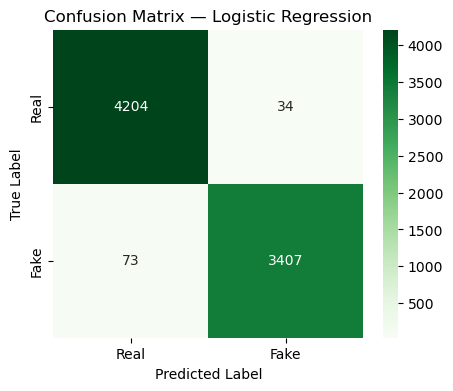

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

## 7. Interpreting the Model: Which Words Drive the Decision?

This is the single biggest advantage of Logistic Regression over more complex models: **you can directly read off which words push toward "Fake" and which push toward "Real,"** because each word literally has one learned weight number attached to it.

In [21]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = lr_model.coef_[0]   # one weight per vocabulary word

# Sort to find the strongest pushers toward each class
top_fake_idx = np.argsort(coefficients)[-15:][::-1]   # most positive weights -> Fake
top_real_idx = np.argsort(coefficients)[:15]          # most negative weights -> Real

print("Top words pushing toward FAKE:")
for idx in top_fake_idx:
    print(f"  {feature_names[idx]:<15} weight = {coefficients[idx]:.3f}")

print("\nTop words pushing toward REAL:")
for idx in top_real_idx:
    print(f"  {feature_names[idx]:<15} weight = {coefficients[idx]:.3f}")

Top words pushing toward FAKE:
  via             weight = 9.118
  image           weight = 8.234
  gop             weight = 5.320
  mr              weight = 4.599
  obama           weight = 4.320
  even            weight = 4.294
  hillary         weight = 4.152
  like            weight = 4.147
  american        weight = 3.805
  wire            weight = 3.788
  america         weight = 3.591
  rep             weight = 3.424
  sen             weight = 3.398
  know            weight = 3.229
  read            weight = 3.007

Top words pushing toward REAL:
  reuters         weight = -23.244
  said            weight = -17.451
  washington      weight = -6.046
  tuesday         weight = -5.044
  wednesday       weight = -4.991
  thursday        weight = -4.362
  monday          weight = -4.279
  dont            weight = -4.256
  friday          weight = -4.233
  im              weight = -3.854
  nov             weight = -3.824
  edt             weight = -3.658
  obamas          weight = -3.53

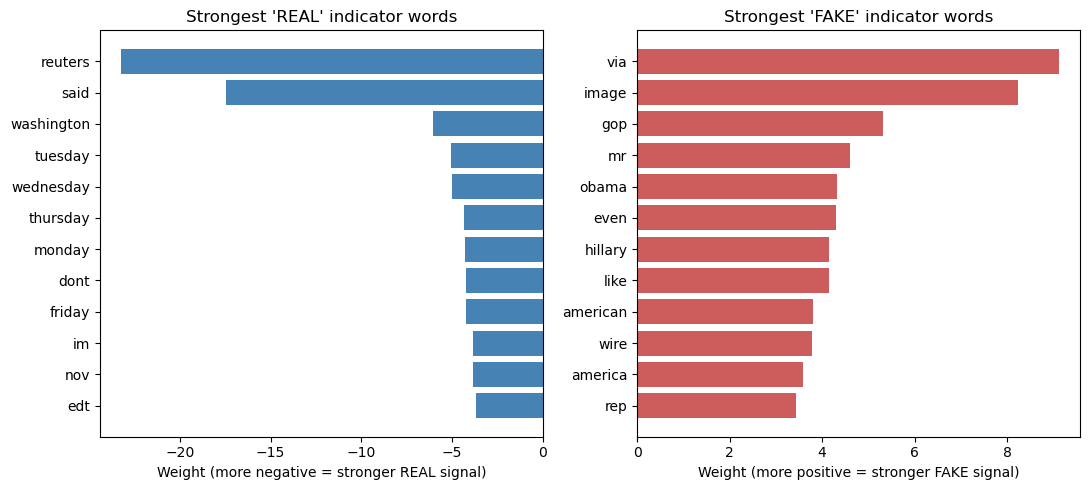

In [22]:
# Visualize it
top_n = 12
fake_words = feature_names[top_fake_idx[:top_n]]
fake_weights = coefficients[top_fake_idx[:top_n]]
real_words = feature_names[top_real_idx[:top_n]]
real_weights = coefficients[top_real_idx[:top_n]]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].barh(real_words[::-1], real_weights[::-1], color='steelblue')
axes[0].set_title("Strongest 'REAL' indicator words")
axes[0].set_xlabel("Weight (more negative = stronger REAL signal)")

axes[1].barh(fake_words[::-1], fake_weights[::-1], color='indianred')
axes[1].set_title("Strongest 'FAKE' indicator words")
axes[1].set_xlabel("Weight (more positive = stronger FAKE signal)")

plt.tight_layout()
plt.show()

**Discussion point for your students:** notice how the "Fake" words tend to be emotionally charged / sensational ("secretly", "shocking", "truth"), while "Real" words tend to be procedural / institutional ("confirmed", "officials", "reported"). This mirrors the deck's claim that linear models can find a clean boundary between *factual reporting* and *hyperbolic misinformation* — and now you can literally point to *why*, word by word.

## 8. Try It Yourself: Predict on a New Tweet

A great in-class exercise: have students write their own tweet and see what the model predicts and how confident it is.

In [23]:
def predict_tweet(raw_text, model=lr_model, vec=vectorizer):
    cleaned = clean_text(raw_text)
    vec_form = vec.transform([cleaned])
    prob_fake = model.predict_proba(vec_form)[0][1]
    label = "FAKE" if prob_fake >= 0.5 else "REAL"
    return label, prob_fake

# Try changing this tweet and re-running the cell
test_tweet = "Officials confirmed the new policy will take effect next month"
label, prob = predict_tweet(test_tweet)
print(f"Tweet: {test_tweet}")
print(f"Prediction: {label}  (P(Fake) = {prob:.3f})")

print()
test_tweet_2 = "SHOCKING you wont believe what they are secretly hiding from everyone"
label2, prob2 = predict_tweet(test_tweet_2)
print(f"Tweet: {test_tweet_2}")
print(f"Prediction: {label2}  (P(Fake) = {prob2:.3f})")

Tweet: Officials confirmed the new policy will take effect next month
Prediction: FAKE  (P(Fake) = 0.587)

Tweet: SHOCKING you wont believe what they are secretly hiding from everyone
Prediction: FAKE  (P(Fake) = 0.933)


## 9. Why Logistic Regression Is a Strong Baseline for Text

This connects directly back to the benchmark numbers from the project deck (Logistic Regression scored **92.4% accuracy**). The reasons it performs so well on TF-IDF text data specifically:

1. **High dimensionality, but linear separability is often enough.** Text turned into TF-IDF can have thousands of features. It turns out that for many text classification tasks, a simple straight-line (hyperplane) boundary already separates the classes quite well — you don't always need a complex non-linear model.

2. **Sparsity.** Most TF-IDF vectors are mostly zeros (each tweet only uses a tiny fraction of the vocabulary). Logistic Regression handles sparse data efficiently and doesn't easily overfit to it, unlike some non-linear models which can latch onto noise.

3. **Speed.** Training involves a relatively cheap optimization (gradient descent on a convex loss function — meaning there's only one global minimum to find, no risk of getting stuck in a bad local optimum).

4. **Interpretability.** As we just saw, every feature has exactly one weight — you can audit *why* the model made a decision, which matters a lot in a sensitive application like flagging "fake news," where false accusations have real consequences.

**The trade-off to flag for students:** because it's a *linear* model, Logistic Regression can struggle if the true decision boundary between Real and Fake tweets is fundamentally non-linear (e.g., depends on subtle *combinations* of words rather than individual word presence). That's part of the motivation for trying SVM next.

## 10. Summary

| Concept | Key Idea |
|---|---|
| Linear combination | $z = \mathbf{w}^T\mathbf{x} + b$ — weighted sum of TF-IDF values |
| Sigmoid | Squashes $z$ into a probability between 0 and 1 |
| Decision rule | Predict "Fake" if $P(\text{Fake}) \geq 0.5$ |
| Loss function | Log loss (binary cross-entropy) — penalizes confident wrong answers heavily |
| Learning | Gradient descent iteratively adjusts weights to minimize loss |
| Interpretability | Each word has one weight — directly readable |
| Why it works for text | Sparse, high-dimensional data is often linearly separable |

**Next session:** we'll look at **SVM**, another linear classifier — but instead of fitting probabilities, it asks a geometric question: *what is the widest possible margin we can draw between Real and Fake tweets?*